In [ ]:
#Run those codes in shell
# The raw data were GSE133361 and GSE165005. The structure model of lysine, TPP riboswitch are obtained from RNAcentral with ID: URS00002D22AE_224308, URS0000ABD47D_1423
#1。 use the downloaded fastq files, and run for both mod and unmod groups.
#LYC
ref=/data1/huangyong/Project/Nanopore/LYC/Lysine_riboswitchlysC.fa
Mod_fastq=/data1/huangyong/Project/Nanopore/LYC/LYC_NAI_1.fastq
Unmod_fastq=/data1/huangyong/Project/Nanopore/LYC/LYC_unmod.fastq
Mod_fast5=/data1/huangyong/Project/Nanopore/LYC/NAI1_fast5
Unmod_fast5=/data1/huangyong/Project/Nanopore/LYC/Unmod_fast5
Mod_Workdir=/data1/huangyong/Project/Nanopore/LYC/NAI1
Unm_Workdir=/data1/huangyong/Project/Nanopore/LYC/Unmod

python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q $Mod_fastq  -s $Mod_fast5  -d $Mod_Workdir -n LYC_NAI -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q $Unmod_fastq  -s $Unmod_fast5  -d $Unm_Workdir -n LYC_Unmod -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m $Mod_Workdir/LYC_NAI.collapsed.event -u $Unm_Workdir/LYC_Unmod.collapsed.event -l 310 -b 5  # l+b=315
python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m $Mod_Workdir/LYC_NAI.collapsed.event.profile.vect -u $Unm_Workdir/LYC_Unmod.collapsed.event.profile.vect -o LYC_scores -s mean 

#TPP 
ref=/data1/huangyong/Project/Nanopore/TPP/TPP.fa
Mod_fastq=/data1/huangyong/Project/Nanopore/TPP/TPP_750_N1.fastq
Unmod_fastq=/data1/huangyong/Project/Nanopore/TPP/TPP_unmod_2.fastq
Mod_fast5=/data1/huangyong/Project/Nanopore/TPP/TPP750_fast5
Unmod_fast5=/data1/huangyong/Project/Nanopore/TPP/TPPunmod_fast5
Mod_Workdir=/data1/huangyong/Project/Nanopore/TPP/NAI1
Unm_Workdir=/data1/huangyong/Project/Nanopore/TPP/Unmod

python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q $Mod_fastq  -s $Mod_fast5  -d $Mod_Workdir -n TPP_750_NAI -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q $Unmod_fastq  -s $Unmod_fast5  -d $Unm_Workdir -n TPP_Unmod 
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m $Mod_Workdir/TPP_NAI.collapsed.event -u $Unm_Workdir/TPP_Unmod.collapsed.event -l 355 -b 5  # l+b=360
python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m $Mod_Workdir/TPP_NAI.collapsed.event.profile.vect -u $Unm_Workdir/TPP_Unmod.collapsed.event.profile.vect -o TPP_scores -s mean 


##使用davinci算法以vect为输入计算分群
cd /data1/huangyong/Project/Nanopore/smStructuremain
python fold-contrafold-uniq-bits-vectors.py -b Lysine2000_011.vect -r /data1/huangyong/Project/Nanopore/LYC/Lysine_riboswitchlysC.fa -t Lysine_riboswitchlysC  -s Lysine_size.tab
修改forgi-vect-ser.txt文件名称
python run-pca-on-forgi-vectors.py -i Lysine2000forgi-vect-ser.txt -t Lysine_riboswitchlysC -c Lysien2000-forgi.csv
python draw-kmeans-clusters.py -i Lysien2000-forgi.csv -t Lysine -n 2 

python fold-contrafold-uniq-bits-vectors.py -b TPP750_011.vect -r /data1/huangyong/Project/Nanopore/TPP/TPP360.fa -t TPP  -s TPP750_size.tab &
修改forgi-vect-ser.txt文件名称
python run-pca-on-forgi-vectors.py -i TPP750forgi-vect-ser.txt -t TPP -c TPP750-forgi.csv
python draw-kmeans-clusters.py -i TPP750-forgi.csv -t TPP750 -n 2 




In [2]:
import os

from sklearn.svm import OneClassSVM
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None
from collections import Counter
import scipy.stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from statistics import mean
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.decomposition import SparsePCA
from sklearn.decomposition import TruncatedSVD
import umap
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN, HDBSCAN
import math
from sklearn.metrics import silhouette_score
#import hypertools as hyp
from RNA import General,Structure, Visual
import matplotlib
%matplotlib inline
from scipy.ndimage import gaussian_filter1d


2026-03-27 19:54:04.061028: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
def CalculateSHAPEFromBitvector_mod(Modvect):
    Percentlist=[]
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    rates=NAI_one/(NAI_one+NAI_zero)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def CalculateSHAPEFromBitvector_control(Modvect,Unmodvect,alpha):
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    DMSO_two=np.sum(Unmodvect==2,axis=0)
    DMSO_zero=np.sum(Unmodvect==0,axis=0)
    delta=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    #delta=list(map(lambda x: x[0]-x[1], zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    rates=NAI_one/(NAI_one+NAI_zero)+np.multiply(delta,alpha)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def Normal_SHAPE(inlist,windowsize=100,step=5): #采用icSHAPE-pipe的策略，在Windows内，top5%为1，最低5%为0
    shape=[[] for i in range(len(inlist))]
    finalshape=[0 for i in range(len(inlist))]
    start=0
    while start+windowsize< len(inlist):
        sublist=np.array(inlist[start:start+windowsize])
        s95=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 95)
        s5=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 5)
        subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in sublist]
        for i in range(windowsize):
            shape[start+i].append(subshape[i])
        start+=step
    #处理最后一个window
    endsublist=np.array(inlist[start:])
    s95=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 95)
    s5=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 5)
    subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in endsublist]
    for i in range(len(endsublist)):
        shape[start+i].append(subshape[i])
    #对每个位置的值求平均
    for i in range(len(inlist)):
        finalshape[i]=mean(shape[i])
    return finalshape
    
def get_index(lst=None, item=''):
    return [index for (index,value) in enumerate(lst) if value == item]


def color_SHAPE(shape_list, cutoff=[0.3, 0.5, 0.7]):
    """
    shape_list              -- A list of SHAPE scores
    cutoff                  -- Cutoff of SHAPE color boundaries.
    
    Transform SHAPE values to color blocks
    """
    color_blocks=[]
    for value in shape_list:
        if value == 'NULL':
            color_blocks.append('lightgray')
        else:
            shape = float(value)
            if shape < cutoff[0]:
                color_blocks.append('black')
            elif shape < cutoff[1]:
                color_blocks.append('blue')
            elif shape < cutoff[2]:
                color_blocks.append('orange')
            else:
                color_blocks.append('red')
    
    return color_blocks

def SHAPEWindowcorrelation(shape1,shape2,windowsize):
    my_list1 = [0 if math.isnan(x) else x for x in shape1]
    my_list2 = [0 if math.isnan(x) else x for x in shape2]
    corre=[]
    start=0
    size=windowsize
    while start+size < len(my_list1):
        end=start+size
        subshape1=my_list1[start:end]
        subshape2=my_list2[start:end]
        t, p = scipy.stats.pearsonr(subshape1, subshape2)
        corre.append(round(t, 3))
        start+=1
    head=[0 for i in range(int(windowsize/2))]
    return head+corre+head

def plotPCA(pcadata,clust_ids,samplelabel,cluser_ratio):
    """
    pcadata                       --The PCA dataframe in which include two columns(PC1 and PC2)
    clust_ids                     --A list of cluster labels of each reads. e.g [0,0,1,2,0,1,2]
    cluser_ratio                  -- The reads ratio of each cluster.
    outfile                       -- The output figure.
    Plot the PCA clustering result 
    """    
    cluster_color = { 0: 'red', 1: '#FF7F00', 2: '#FF00FF',3:'#0000FF',4:'yellow',5:'black'}
    fig = plt.figure(figsize = (6,6))
    ax = fig.add_subplot(111)
    plt.scatter(pcadata['PC1'], pcadata['PC2'], c = [cluster_color[x]  if x in samplelabel else 'gray' for x in clust_ids], s = 20, alpha = 0.50 )
    ax.set_xlabel('PC 1', fontsize = 15)
    ax.set_ylabel('PC 2', fontsize = 15)
    N=len(cluser_ratio)
    for i in range(N):
        ax.text(0.05,0.95-0.05*i,'Cluter{}: {:.2%}'.format(i,cluser_ratio[i]),c=cluster_color[i], fontsize = 12, transform=ax.transAxes)
    ax.set_aspect('equal', 'box')
    plt.axis('equal')
    plt.show()
    #plt.savefig(outfile)
    #plt.close()
def filtVector(vector,posilist,minmod):
    start=posilist[0]
    end=posilist[1]
    temp_vet=vector.iloc[:,start:end].fillna(0)
    temp_totalnum=temp_vet.apply(lambda x: x.sum(),axis=1)
    filtvector=vector[temp_totalnum>minmod]
    return filtvector
def rainbowPlot(probList, ax, length=None, lw=0.8):
    max_height = 0
    for left,right in probList:
        x = (left+right)/2
        width = (right-left)
        height = width*0.01
        max_height = max(max_height, height/2)
        circle = matplotlib.patches.Arc((x, 0), width=width, angle=0, height=height, theta1=0, theta2=180, lw=lw)
        tmp = ax.add_artist(circle)
    ax.set_ylim(0, max_height)
def fill_ends(row):
    first_valid_index = int(row.first_valid_index())
    last_valid_index = int(row.last_valid_index())
    row.iloc[:first_valid_index] = 0
    row.iloc[last_valid_index + 1:] = 0
    return row


In [4]:
#Part1. validate the nanoDISH using Lysine robiswich data
BitvectorLYC=pd.read_csv('/data1/huangyong/Project/Nanopore/LYC/NAI1/split/LYC_20000.MEAN.0005.vect',sep='\t',index_col=0)#2.9万条
DMSOvect=pd.read_csv('/data1/huangyong/Project/Nanopore/LYC/Unmod/split/LYC_20000.mean.event.vect',sep='\t',index_col=0)


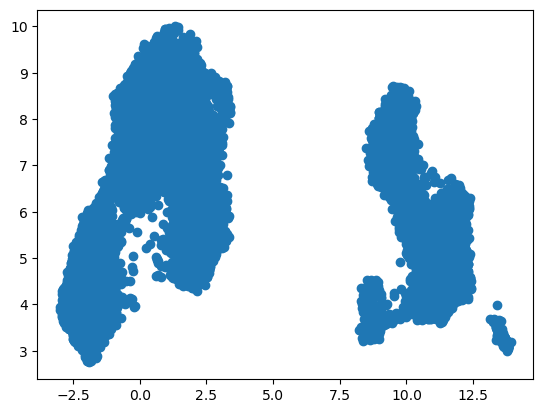

[(0, 13721), (1, 7527)]


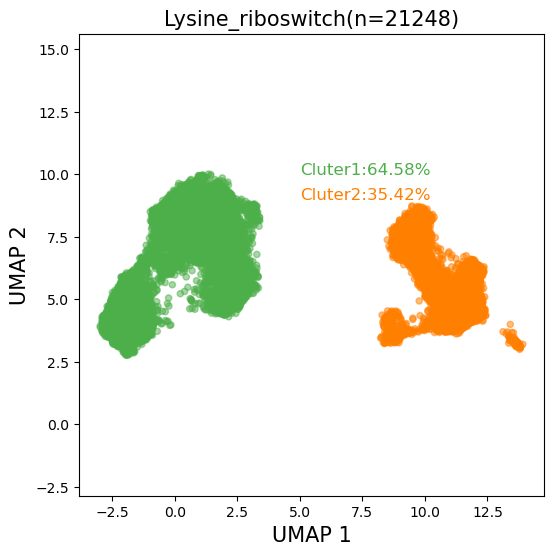

In [5]:
clas_df=BitvectorLYC.apply(fill_ends, axis=1).fillna(2)

UP = umap.UMAP(n_components=2)
LYCUMAP=pd.DataFrame(UP.fit_transform(clas_df) ,columns = ['UMAP1', 'UMAP2'])

plt.scatter(LYCUMAP['UMAP1'], LYCUMAP['UMAP2'])
plt.show()

LYCclustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(LYCUMAP)
LYC_clust_ids = LYCclustering.predict(LYCUMAP).tolist()
#LYCclustering =DBSCAN(eps=0.2, min_samples=3).fit(LYCUMAP)
#LYC_clust_ids =LYCclustering.labels_.tolist()

lists=Counter(LYC_clust_ids).most_common(int(2))
samples={int(k):v for k, v in lists}.keys() 
print(lists)
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',-1:'black'}

LYC_number_c1=LYC_clust_ids.count(0)/len(LYC_clust_ids)
LYC_number_c2=LYC_clust_ids.count(1)/len(LYC_clust_ids)

plt.close()
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(LYCUMAP['UMAP1'], LYCUMAP['UMAP2'], c =  [cluster_color[x]  if x in samples else 'gray' for x in  LYC_clust_ids], s = 20, alpha = 0.50  )
ax.set_xlabel('UMAP 1', fontsize = 15)
ax.set_ylabel('UMAP 2', fontsize = 15)
ax.text(5,10,'Cluter1:{:.2%}'.format(LYC_number_c1), c=cluster_color[0],fontsize = 12)
ax.text(5,9,'Cluter2:{:.2%}'.format(LYC_number_c2),c=cluster_color[1], fontsize = 12)
ax.set_title(f'Lysine_riboswitch(n={len(LYC_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/LYC/NAI1/LYC.validation_20000_0005_UMAP.pdf")
#plt.close()



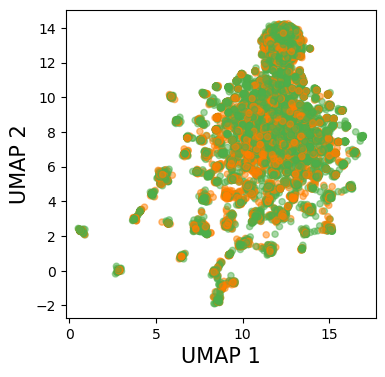

In [6]:
clas_onlyMiscall=clas_df.replace(1, 0)
clas_onlyModify=clas_df.replace(2, 0)
#print(clas_onlyMiscall)
UP = umap.UMAP(n_components=2)
ModUMAP=pd.DataFrame(UP.fit_transform(clas_onlyModify) ,columns = ['UMAP1', 'UMAP2'])

fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(1,1,1) 
#plt.scatter(ModUMAP['UMAP1'], ModUMAP['UMAP2'],c ='gray', s = 20, alpha = 0.50)
plt.scatter(ModUMAP['UMAP1'], ModUMAP['UMAP2'],c = [cluster_color[x]  if x in samples else 'gray' for x in  LYC_clust_ids], s = 20, alpha = 0.50)

ax.set_xlabel('UMAP 1', fontsize = 15)
ax.set_ylabel('UMAP 2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/LYC/NAI1/LYC.validation_20000_0005_UMAP_noMiscall.pdf")
#plt.close()

GGTGAAGATA
TCTCGTTGTT
AGCAATGAGA
TCTCATTGCT


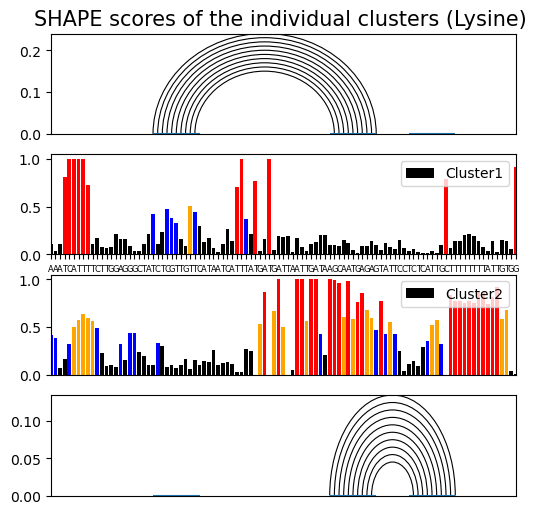

In [7]:
dotfile=General.load_dot('/data1/huangyong/Project/Nanopore/LYC/Lysine_riboswitchlysC.dot')
LYCdot=dotfile['Lysine_riboswitchlysC'][1]
LYCseq=dotfile['Lysine_riboswitchlysC'][0]
LYCpos=[i for i in range(0,len(LYCseq))]

LYC_C1=clas_df.iloc[get_index(LYC_clust_ids,0),:]
LYC_C2=clas_df.iloc[get_index(LYC_clust_ids,1),:]
#LYC_score1=CalculateSHAPEFromBitvector_alpha(LYC_C1,0.05)
#LYC_score2=CalculateSHAPEFromBitvector_alpha(LYC_C2,0.1)
LYC_score1=CalculateSHAPEFromBitvector_control(LYC_C1,DMSOvect,1)
LYC_score2=CalculateSHAPEFromBitvector_control(LYC_C2,DMSOvect,1)


print(LYCseq[50:60])
print(LYCseq[222:232])
print(LYCseq[260:270])
print(LYCseq[277:287])


fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(4,1,1) 
#plt.subplot(4, 1, 1)
plt.title('SHAPE scores of the individual clusters (Lysine) ',fontsize=15)
#plt.scatter([i for i in range(len(LYCcorrelation))], correlation_smooth, s = 1,color ='gray',label='Correlation' )
rainbowlist1=[[222,270],[223,269],[224,268],[225,267],[226,266],[227,265],[228,264],[229,263],[230,262],[231,261]]
rainbowPlot(rainbowlist1,ax)
plt.hlines(y=0, xmin=50, xmax=60)
plt.hlines(y=0, xmin=222, xmax=232)
plt.hlines(y=0, xmin=260, xmax=270)
plt.hlines(y=0, xmin=277, xmax=287)
plt.xticks([])

#plt.legend(loc="upper right")
plt.xlim(200,300)
#plt.show()

ax = fig.add_subplot(4,1,2) 
plt.bar([x+3 for x in LYCpos], LYC_score1,  color =color_SHAPE(LYC_score1) ,label='Cluster1')
plt.xticks([])
plt.legend(loc="upper right")
ax.set_xticks(LYCpos, fontsize=6)
ax.set_xticklabels(LYCseq, fontsize=6)
plt.xlim(200,300)

ax = fig.add_subplot(4,1,3) 
plt.bar([x+3 for x in LYCpos], LYC_score2,  color =color_SHAPE(LYC_score2) ,label='Cluster2')
plt.xticks([])
plt.legend(loc="upper right")
plt.xlim(200,300)


ax = fig.add_subplot(4,1,4) 
rainbowlist2=[[260,287],[261,286],[262,285],[263,284],[264,283],[265,282],[266,281],[267,280],[268,279],[269,278]]
rainbowPlot(rainbowlist2,ax)
plt.hlines(y=0, xmin=50, xmax=60)
plt.hlines(y=0, xmin=222, xmax=232)
plt.hlines(y=0, xmin=260, xmax=270)
plt.hlines(y=0, xmin=277, xmax=287)
plt.xticks([])

plt.xlim(200,300)
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/LYC/NAI1/LYC.validation_2.21.pdf")
#plt.close()

In [8]:

CMDLYC_noli=Visual.Plot_RNAStructure_Shape(LYCseq, LYCdot, [0,0]+LYC_score2[0:313],mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=-23, title = ("cluster1_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMDLYC_noli)


java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN CCAAGUAAUACGACUCACUAUAGGAAUUUCAUAGUUAGAUCGUGUUAUAUGGUGAAGAUAGAGGUGCGAACUUCAAGAGUAUGCCUUUGGAGAAAGAUGGAUUCUGUGAAAAAGGCUGAAAGGGGAGCGUCGCCGAAGCAAAUAAAACCCCAUCGGUAUUAUUUGCUGGCCGUGCAUUGAAUAAAUGUAAGGCUGUCAAGAAAUCAUUUUCUUGGAGGGCUAUCUCGUUGUUCAUAAUCAUUUAUGAUGAUUAAUUGAUAAGCAAUGAGAGUAUUCCUCUCAUUGCUUUUUUUUAUUGUGGACAAAGCGCUCUUU -structureDBN ".......................................................((((((....(((((((((.......((((((((....................))))))))......)))).)))))...((((((((((((.......))))))))))))(((((((((((.....))))))))))).(((((((......)))))))....)))))).........................................................................................." -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#B61D22" -basesStyle2 "fill=#ED9616" -basesStyle3 "fill=#194399" -basesStyle4 "fill=#040000" -basesStyle5 "fill=#828282" -applyBasesStyle1on "38,39,40,41,42,44,45,46,47,48,49,52,54,102,103,10

In [10]:
dotfile=General.load_dot('/data1/huangyong/Project/Nanopore/LYC/Lysine_anti-terminator.dot')
LYCdot=dotfile['Lysine_riboswitchlysC'][1]
LYCseq=dotfile['Lysine_riboswitchlysC'][0].replace('T','U')
LYCpos=[i for i in range(0,len(LYCseq))]

print(len(LYCseq))
print(len(LYC_score1))
CMDLYC_noli=Visual.Plot_RNAStructure_Shape(LYCseq, LYCdot, [0,0]+LYC_score1[0:313],mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=-23, title = ("cluster1_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMDLYC_noli)


315
315
java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN CCAAGUAAUACGACUCACUAUAGGAAUUUCAUAGUUAGAUCGUGUUAUAUGGUGAAGAUAGAGGUGCGAACUUCAAGAGUAUGCCUUUGGAGAAAGAUGGAUUCUGUGAAAAAGGCUGAAAGGGGAGCGUCGCCGAAGCAAAUAAAACCCCAUCGGUAUUAUUUGCUGGCCGUGCAUUGAAUAAAUGUAAGGCUGUCAAGAAAUCAUUUUCUUGGAGGGCUAUCUCGUUGUUCAUAAUCAUUUAUGAUGAUUAAUUGAUAAGCAAUGAGAGUAUUCCUCUCAUUGCUUUUUUUUAUUGUGGACAAAGCGCUCUUU -structureDBN "..........................................................(((....(((((((((.......((((((((....................))))))))......)))).)))))...((((((((((((.......))))))))))))(((((((((((.....))))))))))).(((((((......)))))))....)))((((((((((............................))))))))))............................................." -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#B61D22" -basesStyle2 "fill=#ED9616" -basesStyle3 "fill=#194399" -basesStyle4 "fill=#040000" -basesStyle5 "fill=#828282" -applyBasesStyle1on "37,38,44,45,46,47,48,49,52,54,95,96,103,1

In [12]:
#compare with DaVinci
dotfile=General.load_dot('/data1/huangyong/Project/Nanopore/LYC/Lysine_terminator.dot')
LYCdot=dotfile['Lysine_riboswitchlysC'][1]
dotfile_anti=General.load_dot('/data1/huangyong/Project/Nanopore/LYC/Lysine_riboswitchlysC.dot')
LYCdot_anti=dotfile_anti['Lysine_riboswitchlysC'][1]

Dar4189_dot='.((.(((((((((((.(((((.(((())))))))).)).))))))))).)).........(((((....)))))..(((...(((((....(((.(((((.((((.((((.((.(((((..((((......((....))........)))).))))).)).)....(((((.((((((.....)))))).)))))))))))).))))))))....)))))...))).........................................................................................'
Dar751_dot='..............((((((((.........................)))))))).....(((((....)))))........((((.........((.....))........))))......((((((((...(..(((((((((.............))))))))))(((...((((.....))))...))).((.........................................................................................................))...)))))))).'

score4189=[1 if i=='.' else 0 for i in list(Dar4189_dot)]
score751=[1 if i=='.' else 0 for i in list(Dar751_dot)]
print(len(LYCdot_anti[10:270]))
print(len(score4189[8:268]))
start=0
print(General.calc_AUC_v2(LYCdot_anti[10:270], score4189[8+start:268+start]))
print(General.calc_AUC_v2(LYCdot[10:270], score751[8+start:268+start]))
print(LYCdot[10:270])
print(LYCdot_anti[10:270])
print(Dar4189_dot[8+start:268+start])
print(Dar751_dot[8+start:268+start])
0.52
0.65



260
260
0.5182553295760843
0.6277538314176245
.............................................((((((....(((((((((.......((((((((....................))))))))......)))).)))))...((((((((((((.......))))))))))))(((((((((((.....))))))))))).(((((((......)))))))....))))))...................................((((((((((
.............................................((((((....(((((((((.......((((((((....................))))))))......)))).)))))...((((((((((((.......))))))))))))(((((((((((.....))))))))))).(((((((......)))))))....)))))).............................................
(((((((.(((((.(((())))))))).)).))))))))).)).........(((((....)))))..(((...(((((....(((.(((((.((((.((((.((.(((((..((((......((....))........)))).))))).)).)....(((((.((((((.....)))))).)))))))))))).))))))))....)))))...)))..........................................
......((((((((.........................)))))))).....(((((....)))))........((((.........((.....))........))))......((((((((...(..(((((((((.............))))))))))(((...((((.

0.65

In [15]:
dotfile4189=General.load_fasta('/data1/huangyong/Project/Nanopore/smStructuremain/bit_4189.fold')
CMDLYC4189=Visual.Plot_RNAStructure_Base(list(dotfile4189.values())[0], list(dotfile4189.values())[1], bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=-23, title = ("4189_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMDLYC4189)

java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN CCAAGUAAUACGACUCACUAUAGGAAUUUCAUAGUUAGAUCGUGUUAUAUGGUGAAGAUAGAGGUGCGAACUUCAAGAGUAUGCCUUUGGAGAAAGAUGGAUUCUGUGAAAAAGGCUGAAAGGGGAGCGUCGCCGAAGCAAAUAAAACCCCAUCGGUAUUAUUUGCUGGCCGUGCAUUGAAUAAAUGUAAGGCUGUCAAGAAAUCAUUUUCUUGGAGGGCUAUCUCGUUGUUCAUAAUCAUUUAUGAUGAUUAAUUGAUAAGCAAUGAGAGUAUUCCUCUCAUUGCUUUUUUUUAUUGUGGACAAAGCGCUCUUU -structureDBN ".((.(((((((((((.(((((.(((())))))))).)).))))))))).)).........(((((....)))))..(((...(((((....(((.(((((.((((.((((.((.(((((..((((......((....))........)))).))))).)).)....(((((.((((((.....)))))).)))))))))))).))))))))....)))))...)))........................................................................................." -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#CCFFCC" -basesStyle2 "fill=#CCFFFF" -basesStyle3 "fill=#FFFFCC" -basesStyle4 "fill=#FFCCFF" -applyBasesStyle1on "3,4,7,8,10,13,17,20,22,25,26,31,33,37,39,47,49,55,56,58,60,62,69,70,75,76,78,

In [16]:
dotfile751=General.load_fasta('/data1/huangyong/Project/Nanopore/smStructuremain/bit_751.fold')
CMDLYC751=Visual.Plot_RNAStructure_Base(list(dotfile751.values())[0], list(dotfile751.values())[1], bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=-23, title = ("751_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMDLYC751)

java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN CCAAGUAAUACGACUCACUAUAGGAAUUUCAUAGUUAGAUCGUGUUAUAUGGUGAAGAUAGAGGUGCGAACUUCAAGAGUAUGCCUUUGGAGAAAGAUGGAUUCUGUGAAAAAGGCUGAAAGGGGAGCGUCGCCGAAGCAAAUAAAACCCCAUCGGUAUUAUUUGCUGGCCGUGCAUUGAAUAAAUGUAAGGCUGUCAAGAAAUCAUUUUCUUGGAGGGCUAUCUCGUUGUUCAUAAUCAUUUAUGAUGAUUAAUUGAUAAGCAAUGAGAGUAUUCCUCUCAUUGCUUUUUUUUAUUGUGGACAAAGCGCUCUUU -structureDBN "..............((((((((.........................)))))))).....(((((....)))))........((((.........((.....))........))))......((((((((...(..(((((((((.............))))))))))(((...((((.....))))...))).((.........................................................................................................))...))))))))." -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#CCFFCC" -basesStyle2 "fill=#CCFFFF" -basesStyle3 "fill=#FFFFCC" -basesStyle4 "fill=#FFCCFF" -applyBasesStyle1on "3,4,7,8,10,13,17,20,22,25,26,31,33,37,39,47,49,55,56,58,60,62,69,70,75,76,78,

In [13]:
#TPP riboswitch
BitvectorTPP750=pd.read_csv('/data1/huangyong/Project/Nanopore/TPP/NAI/TPP_750_multi/TPP_750part.mean.vect',sep='\t',index_col=0)
DMSOTPPnoli=pd.read_csv('/data1/huangyong/Project/Nanopore/TPP/Unmod/TPP_Unmod.median.event.vect',sep='\t',index_col=0)

TPPfile=General.load_fasta('/data1/huangyong/Project/Nanopore/TPP/TPP.fa')
TPPseq=TPPfile['TPP'][105:219].replace('T','U')
TPPlist=[i for i in range(0,114)]

TPPdot='..........(((((((((.((((((.....)))))......(((((.....))))))..)))).....((((..((((......))))..))))..)))))............'
print(TPPseq)

AUUCGUUUAACCACUAGGGGUGUCCUUCAUAAGGGCUGAGAUAAAAGUGUGACUUUUAGACCCUCAUAACUUGAACAGGUUCAGACCUGCGUAGGGAAGUGGAGCGUAUUUGUG


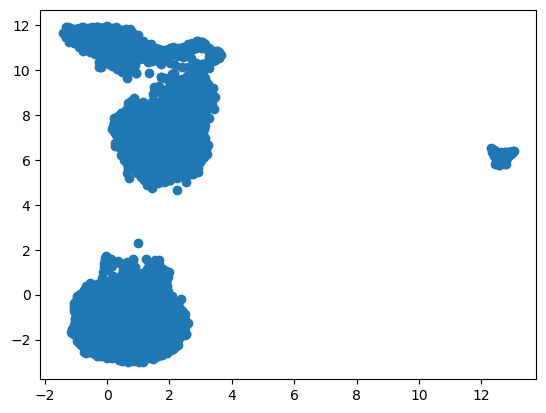

[(1, 10116), (0, 9720)]


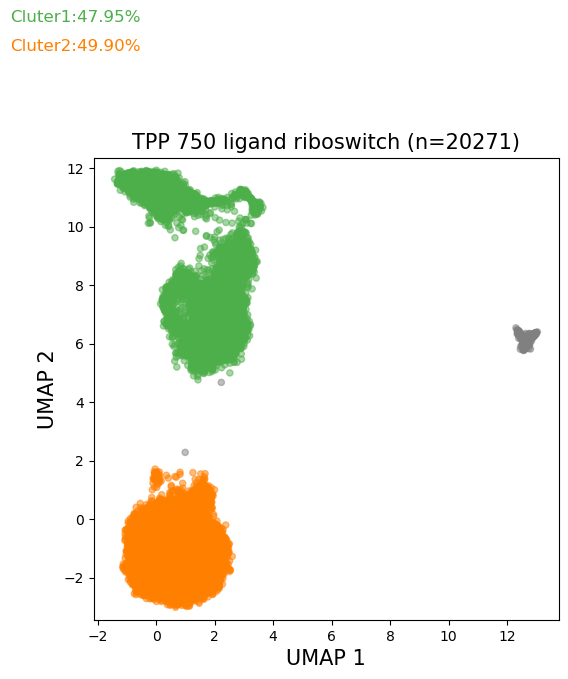

In [14]:
TPP750_classdf=BitvectorTPP750.apply(fill_ends, axis=1).fillna(2).iloc[:,1:360]

UP = umap.UMAP(n_components=2)

TPP750UMAP = pd.DataFrame(UP.fit_transform(TPP750_classdf),columns = ['UMAP1', 'UMAP2'])
plt.scatter(TPP750UMAP['UMAP1'], TPP750UMAP['UMAP2'])
plt.show()

TPP750clustering =DBSCAN(eps=0.4, min_samples=2).fit(TPP750UMAP)
TPP750_clust_ids =TPP750clustering.labels_.tolist()
#TPP750clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=2).fit(TPP750UMAP)
#TPP750_clust_ids = TPP750clustering.predict(TPP750UMAP).tolist()
print(Counter(TPP750_clust_ids).most_common(int(2)))
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

TPP750_number_c1=TPP750_clust_ids.count(0)/len(TPP750_clust_ids)
TPP750_number_c2=TPP750_clust_ids.count(1)/len(TPP750_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(TPP750UMAP['UMAP1'], TPP750UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1] else 'gray' for x in  TPP750_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP 1', fontsize = 15)
ax.set_ylabel('UMAP 2', fontsize = 15)
ax.text(-5,17,'Cluter1:{:.2%}'.format(TPP750_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(-5,16,'Cluter2:{:.2%}'.format(TPP750_number_c2),c=cluster_color[1], fontsize = 12)
#ax.text(1,1.3,'Cluter3:{:.2%}'.format(TPPnoli_number_c3),c=cluster_color[2], fontsize = 12)

ax.set_title(f'TPP 750 ligand riboswitch (n={len(TPP750_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/TPP/NAI/TPP_750_multi/TPP_750_clusers.pdf")
#plt.close()

In [238]:
silhouette_score(TPP750UMAP, TPP750_clust_ids)

0.77393633

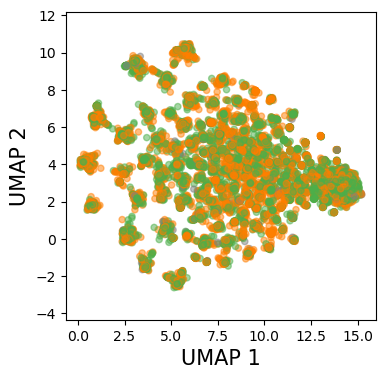

In [19]:
TPP750_onlyModify=TPP750_classdf.replace(2, 0)
#print(clas_onlyMiscall)
UP = umap.UMAP(n_components=2)
TPP750ModUMAP=pd.DataFrame(UP.fit_transform(TPP750_onlyModify) ,columns = ['UMAP1', 'UMAP2'])

fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(1,1,1) 
plt.scatter(TPP750ModUMAP['UMAP1'], TPP750ModUMAP['UMAP2'],c =[cluster_color[x]  if x in [0,1] else 'gray' for x in  TPP750_clust_ids], s = 20, alpha = 0.50)
ax.set_xlabel('UMAP 1', fontsize = 15)
ax.set_ylabel('UMAP 2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/TPP/NAI-noli/split/TPP_750_noMiscall_UMAP.pdf")
#plt.close()

0.7004310344827586
0.7570812807881774


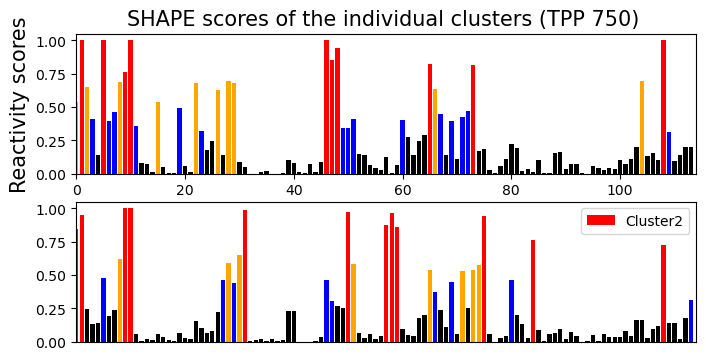

java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN AUUCGUUUAACCACUAGGGGUGUCCUUCAUAAGGGCUGAGAUAAAAGUGUGACUUUUAGACCCUCAUAACUUGAACAGGUUCAGACCUGCGUAGGGAAGUGGAGCGUAUUUGUG -structureDBN "..........(((((((((.((((((.....)))))......(((((.....))))))..)))).....((((..((((......))))..))))..)))))............" -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#B61D22" -basesStyle2 "fill=#ED9616" -basesStyle3 "fill=#194399" -basesStyle4 "fill=#040000" -basesStyle5 "fill=#828282" -applyBasesStyle1on "1,2,10,11,32,51,58,59,60,76,85,109" -applyBasesStyle2on "9,29,31,52,66,72,74,75" -applyBasesStyle3on "6,28,30,47,48,67,70,81,114" -applyBasesStyle4on "3,4,5,7,8,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,33,34,35,36,37,38,39,40,41,42,43,44,45,46,49,50,53,54,55,56,57,61,62,63,64,65,68,69,71,73,77,78,79,80,82,83,84,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,110,111,112,113"  -spaceBetweenBases "0.8" -periodNum

In [20]:
TPP750_C1=TPP750_classdf.iloc[get_index(TPP750_clust_ids,0),:]
TPP750_C2=TPP750_classdf.iloc[get_index(TPP750_clust_ids,1),:]

TPP750_score1=CalculateSHAPEFromBitvector_control(TPP750_C1,DMSOTPPnoli,0)
TPP750_score2=CalculateSHAPEFromBitvector_control(TPP750_C2,DMSOTPPnoli,1)
print(General.calc_AUC_v2(TPPdot, TPP750_score1[102:216]))
print(General.calc_AUC_v2(TPPdot, TPP750_score2[102:216]))

fig = plt.figure(figsize = (8,4))
ax = fig.add_subplot(2,1,1) 
plt.bar(TPPlist, TPP750_score1[102:216],  color =color_SHAPE(TPP750_score1[102:216]) )
plt.ylabel("Reactivity scores",fontsize=15) 
plt.title('SHAPE scores of the individual clusters (TPP 750) ',fontsize=15)
plt.xlim(0,114)

plt.subplot(2, 1, 2)
plt.bar(TPPlist, TPP750_score2[102:216],  color =color_SHAPE(TPP750_score2[102:216]) ,label='Cluster2')
plt.xticks([])
plt.legend(loc="upper right")
plt.xlim(0,114)
#plt.xticks([100,125,225])

plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/TPP/NAI/TPP_750_multi/TPP_750_scores.pdf")
#plt.close()

CMDTPP_750=Visual.Plot_RNAStructure_Shape(TPPseq, TPPdot, TPP750_score2[102:216] ,mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=105, title = ("750cluster2_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMDTPP_750)

CMDTPP_750_2=Visual.Plot_RNAStructure_Shape(TPPseq, TPPdot, TPP750_score1[102:216] ,mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=105, title = ("750cluster1_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMDTPP_750_2)

In [240]:
CMDTPP_750=Visual.Plot_RNAStructure_Shape(TPPseq, TPPdot, TPP750_score1[102:216] ,mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=105, title = ("750cluster1_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMDTPP_750)
print(General.calc_AUC_v2(TPPdot, TPP750_score1[102:216]))


java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN AUUCGUUUAACCACUAGGGGUGUCCUUCAUAAGGGCUGAGAUAAAAGUGUGACUUUUAGACCCUCAUAACUUGAACAGGUUCAGACCUGCGUAGGGAAGUGGAGCGUAUUUGUG -structureDBN "..........(((((((((.((((((.....)))))......(((((.....))))))..)))).....((((..((((......))))..))))..)))))............" -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#B61D22" -basesStyle2 "fill=#ED9616" -basesStyle3 "fill=#194399" -basesStyle4 "fill=#040000" -basesStyle5 "fill=#828282" -applyBasesStyle1on "1,2,6,9,10,11,32,44,47,60,61,76,81,102" -applyBasesStyle2on "5,8,29,51,59,62,70,89" -applyBasesStyle3on "4,16,28,30,31,41,43,52,58,72,75,85,103" -applyBasesStyle4on "3,7,12,13,14,15,17,18,19,20,21,22,23,24,25,26,27,33,34,35,36,37,38,39,40,42,45,46,48,49,50,53,54,55,56,57,63,64,65,66,67,68,69,71,73,74,77,78,79,80,82,83,84,86,87,88,90,91,92,93,94,95,96,97,98,99,100,101,104,105,106,107,108,109,110,111,112,113,114"  -spaceBetweenBases "0.8" -periodNum

In [241]:
CMDTPP_750=Visual.Plot_RNAStructure_Shape(TPPseq, TPPdot, TPP750_score2[102:216] ,mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=105, title = ("750cluster2_structure"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMDTPP_750)
print(General.calc_AUC_v2(TPPdot, TPP750_score2[102:216]))


java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN AUUCGUUUAACCACUAGGGGUGUCCUUCAUAAGGGCUGAGAUAAAAGUGUGACUUUUAGACCCUCAUAACUUGAACAGGUUCAGACCUGCGUAGGGAAGUGGAGCGUAUUUGUG -structureDBN "..........(((((((((.((((((.....)))))......(((((.....))))))..)))).....((((..((((......))))..))))..)))))............" -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#B61D22" -basesStyle2 "fill=#ED9616" -basesStyle3 "fill=#194399" -basesStyle4 "fill=#040000" -basesStyle5 "fill=#828282" -applyBasesStyle1on "1,2,10,11,32,51,58,59,60,76,85,109" -applyBasesStyle2on "9,29,31,52,66,72,74,75" -applyBasesStyle3on "6,28,30,47,48,67,70,81,114" -applyBasesStyle4on "3,4,5,7,8,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,33,34,35,36,37,38,39,40,41,42,43,44,45,46,49,50,53,54,55,56,57,61,62,63,64,65,68,69,71,73,77,78,79,80,82,83,84,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,110,111,112,113"  -spaceBetweenBases "0.8" -periodNum

In [10]:
#计算davinci算法得到的两个结构的AUC
TPPdot='..........(((((((((.((((((.....)))))......(((((.....))))))..)))).....((((..((((......))))..))))..)))))............'
dot542='.((((((..............))))))...((((((....(((((((...(((...........................((.(((............................))).))..))).)))))))..............(((.........)))...(((((..........(((((....)))))(((((.(((((((.(((....))).))))))).)))))........(((((((((((((....)))))))))))))...........)))))...............))))))........((.((......)).)).....((((((.((....))...))))))'
dot136='...................(((((((((.........((((.((((....))))..))))...)))))))))..................................................(((....)))..............(((((((...)))))))..(((((.....(.(..(((((....)))))..).)((((.(((..((((...............))))))).))))(((((((((((((....)))))))))))))...........)))))..................(((....))).((.((......)).)).....((((((.((....))...))))))'

score542=[1 if i=='.' else 0 for i in list(dot542)]
score136=[1 if i=='.' else 0 for i in list(dot136)]

start=0
print(General.calc_AUC_v2(TPPdot, score542[102+start:216+start]))
print(General.calc_AUC_v2(TPPdot, score136[102+start:216+start]))

print(TPPdot)
print(dot542[102+start:216+start])
print(dot136[102+start:216+start])
0.49
0.45
